# Logistic Regression and Classifications

In [1]:
import os 
os.environ["PYSPARK_PYTHON"] = 'python'

In [2]:
from pyspark.sql import SparkSession

In [3]:
spark = SparkSession.builder.appName("TelecomChurnAnalysis").master("local[*]").getOrCreate()


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
from pyspark.ml.feature import *
from pyspark.ml.classification import *
from pyspark.ml import pipeline
from pyspark.sql.functions import *
from pyspark.sql.types import *
import pyspark.sql.functions

In [7]:
df = spark.read.csv("dataset/telecom_churn.csv", header = True, inferSchema=True)
df.show(5)

+----------+------+-------------+-------+----------+------+------------+----------------+---------------+-------------------+-------------------+-------------------+--------------+----------------+--------------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|   MultipleLines|InternetService|     OnlineSecurity|        TechSupport|        StreamingTV|      Contract|PaperlessBilling|       PaymentMethod|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+----------------+---------------+-------------------+-------------------+-------------------+--------------+----------------+--------------------+--------------+------------+-----+
|  CUS00001|  Male|            0|    Yes|        No|    42|         Yes|              No|            DSL|                 No|                Yes|                Yes|      One year|             Yes|    Electronic check|         72.56|     305

In [8]:
print("Rows:",df.count())
print("Columns:" , len(df.columns))

Rows: 7043
Columns: 18


In [9]:
from pyspark.sql.functions import sum as spark_sum

missing = df.select([
    spark_sum(when(col(c).isNull(),1).otherwise(0)).alias(c)
    for c in df.columns
])

missing.show()

+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+-----------+-----------+--------+----------------+-------------+--------------+------------+-----+
|customerID|gender|SeniorCitizen|Partner|Dependents|tenure|PhoneService|MultipleLines|InternetService|OnlineSecurity|TechSupport|StreamingTV|Contract|PaperlessBilling|PaymentMethod|MonthlyCharges|TotalCharges|Churn|
+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+-----------+-----------+--------+----------------+-------------+--------------+------------+-----+
|         0|     0|            0|      0|         0|     0|           0|            0|              0|             0|          0|          0|       0|               0|            0|             0|          90|    0|
+----------+------+-------------+-------+----------+------+------------+-------------+---------------+--------------+-----------+-------

In [10]:
for col_name in df.columns:
    null_count = df.filter(
        col(col_name).isNull() | (col(col_name) == '')
    ).count()
    if null_count > 0:
        print(col_name, "->", null_count, "missing values")

TotalCharges -> 90 missing values


In [11]:
df = df.withColumn(
    'TotalCharges',
    when(col('TotalCharges') == '', '0').otherwise(col('TotalCharges')).cast(DoubleType())
)

In [12]:
df.select("TotalCharges").show(5)

+------------+
|TotalCharges|
+------------+
|     3052.17|
|     7583.53|
|     1642.77|
|     4458.28|
|     1851.24|
+------------+
only showing top 5 rows



In [13]:
df = df.fillna({'TotalCharges' : 0.0})
remaining_blanks = df.filter (col('TotalCharges').isNull()).count()
print(remaining_blanks)

0


In [14]:
df.printSchema()

root
 |-- customerID: string (nullable = true)
 |-- gender: string (nullable = true)
 |-- SeniorCitizen: integer (nullable = true)
 |-- Partner: string (nullable = true)
 |-- Dependents: string (nullable = true)
 |-- tenure: integer (nullable = true)
 |-- PhoneService: string (nullable = true)
 |-- MultipleLines: string (nullable = true)
 |-- InternetService: string (nullable = true)
 |-- OnlineSecurity: string (nullable = true)
 |-- TechSupport: string (nullable = true)
 |-- StreamingTV: string (nullable = true)
 |-- Contract: string (nullable = true)
 |-- PaperlessBilling: string (nullable = true)
 |-- PaymentMethod: string (nullable = true)
 |-- MonthlyCharges: double (nullable = true)
 |-- TotalCharges: double (nullable = false)
 |-- Churn: string (nullable = true)



In [15]:
df.select("Churn").show()

+-----+
|Churn|
+-----+
|   No|
|  Yes|
|   No|
|   No|
|   No|
|  Yes|
|   No|
|  Yes|
|  Yes|
|   No|
|  Yes|
|   No|
|  Yes|
|   No|
|   No|
|  Yes|
|  Yes|
|   No|
|  Yes|
|   No|
+-----+
only showing top 20 rows



In [16]:
df = df.withColumn(
    'ChurnLabel',
    when(col('Churn') == 'Yes', 1.0).otherwise(0.0)
)

df.groupBy("ChurnLabel").count().show()

+----------+-----+
|ChurnLabel|count|
+----------+-----+
|       0.0| 5277|
|       1.0| 1766|
+----------+-----+



In [17]:
df.select('Partner').show()

+-------+
|Partner|
+-------+
|    Yes|
|    Yes|
|     No|
|    Yes|
|    Yes|
|    Yes|
|    Yes|
|     No|
|     No|
|     No|
|     No|
|     No|
|     No|
|     No|
|    Yes|
|     No|
|     No|
|     No|
|     No|
|    Yes|
+-------+
only showing top 20 rows



In [18]:
cat_cols = [
    'gender', 'Partner', 'Dependents', 'PhoneService',
    'MultipleLines', 'InternetService', 'OnlineSecurity',
    'TechSupport', 'StreamingTV', 'Contract',
    'PaperlessBilling', 'PaymentMethod'
]

num_cols = ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [19]:
indexers = []
for c in cat_cols:
    idx = StringIndexer(inputCol= c , outputCol= c + '_idx', handleInvalid= 'keep')
    indexers.append(idx)
len(indexers)

12

In [20]:
encoders = []
for c in cat_cols:
    enc = OneHotEncoder(inputCol= c + '_idx',  outputCol= c + '_ohe', dropLast = True)
    encoders.append(enc)

len(encoders)

12

In [21]:
ohe_cols = [c + '_ohe' for c in cat_cols]
all_feature_cols = num_cols + ohe_cols

assembler = VectorAssembler(inputCols = all_feature_cols, outputCol= 'features', handleInvalid= 'keep')

In [22]:
num_cols

['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']

In [23]:
from pyspark.ml import Pipeline

In [24]:
prep_pipeline = Pipeline(stages = indexers + encoders +[assembler])
prep_model = prep_pipeline.fit(df)
df_prep = prep_model.transform(df)
df_prep.select("InternetService_ohe").show(5)

+-------------------+
|InternetService_ohe|
+-------------------+
|      (3,[1],[1.0])|
|      (3,[0],[1.0])|
|      (3,[2],[1.0])|
|      (3,[2],[1.0])|
|      (3,[0],[1.0])|
+-------------------+
only showing top 5 rows



In [25]:
train_data , test_data = df_prep.randomSplit([0.7, 0.3], seed = 42)
print(train_data.count())
print(test_data.count())

5036
2007


In [26]:
train_data.groupBy('ChurnLabel').count().show()

+----------+-----+
|ChurnLabel|count|
+----------+-----+
|       0.0| 3781|
|       1.0| 1255|
+----------+-----+



In [27]:
test_data.groupBy('ChurnLabel').count().show()

+----------+-----+
|ChurnLabel|count|
+----------+-----+
|       0.0| 1496|
|       1.0|  511|
+----------+-----+



In [28]:
logR = LogisticRegression(
    labelCol= 'ChurnLabel',
    featuresCol= 'features',
    maxIter= 100,
    regParam = 0.01
)

print("Regression Model")

lr_model = logR.fit(train_data)
print(lr_model)

Regression Model
LogisticRegressionModel: uid=LogisticRegression_e4c3bba24093, numClasses=2, numFeatures=36


In [29]:
lr_pred = lr_model.transform(test_data)

for c in lr_pred.columns[-5:]:
    print(c)

PaymentMethod_ohe
features
rawPrediction
probability
prediction


In [30]:
lr_pred.select (
'customerID', 'ChurnLabel', 'rawPrediction', "probability", 'prediction').show(5)

+----------+----------+--------------------+--------------------+----------+
|customerID|ChurnLabel|       rawPrediction|         probability|prediction|
+----------+----------+--------------------+--------------------+----------+
|  CUS00003|       0.0|[1.22555480001600...|[0.77303961345466...|       0.0|
|  CUS00007|       0.0|[2.23779686486223...|[0.90359270731639...|       0.0|
|  CUS00009|       1.0|[0.69730973030122...|[0.66759103509732...|       0.0|
|  CUS00010|       0.0|[1.70109732381818...|[0.84567799737913...|       0.0|
|  CUS00014|       0.0|[0.67944909609309...|[0.66361573027120...|       0.0|
+----------+----------+--------------------+--------------------+----------+
only showing top 5 rows



In [31]:
from pyspark.ml.evaluation import *

In [32]:
evaluator_f1 = MulticlassClassificationEvaluator(
        labelCol='ChurnLabel', predictionCol='prediction', metricName='f1'
)

lr_f1_eval = evaluator_f1.evaluate(lr_pred)
print(lr_f1_eval)

0.6816304449219187


In [33]:
lr_TP = lr_pred.filter((col('ChurnLabel') == 1) & (col('prediction') == 1)).count()
lr_TN = lr_pred.filter((col('ChurnLabel') == 0) & (col('prediction') == 0)).count()
lr_FP = lr_pred.filter((col('ChurnLabel') == 0) & (col('prediction') == 1)).count()
lr_FN = lr_pred.filter((col('ChurnLabel') == 1) & (col('prediction') == 0)).count()


print("TP" , lr_TP)
print("TN", lr_TN)
print("FP", lr_FP)
print("FN", lr_FN)

TP 63
TN 1429
FP 67
FN 448


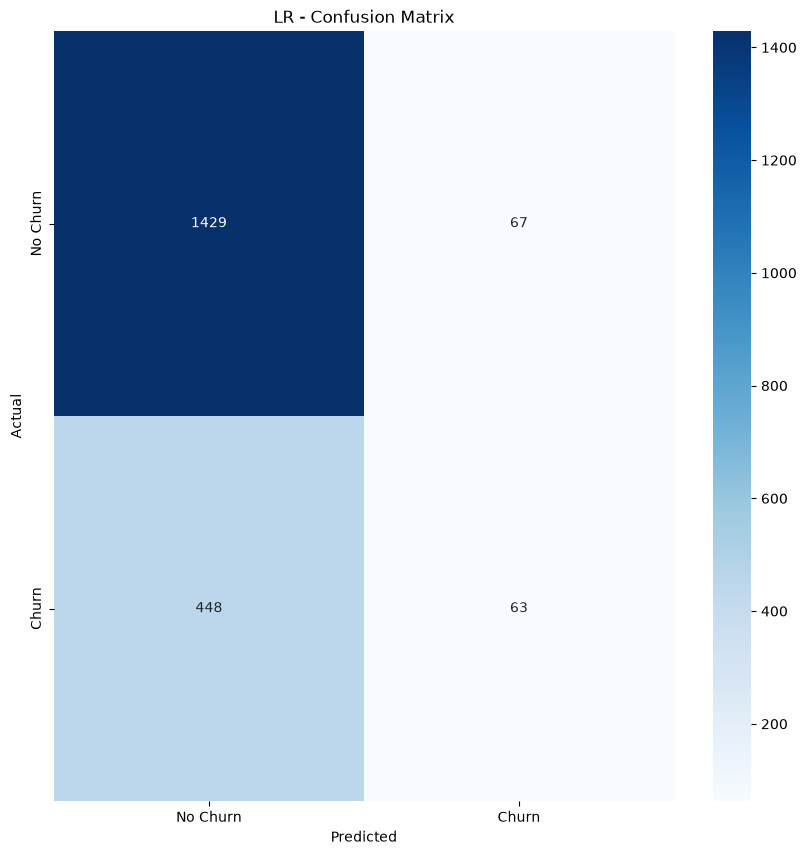

In [34]:
cm = np.array([[lr_TN, lr_FP], [lr_FN, lr_TP]])

plt.figure(figsize= (10,10))
sns.heatmap(cm , annot = True ,
           xticklabels= ["No Churn", 'Churn'],
           yticklabels=['No Churn', 'Churn'],
           cmap= 'Blues',
           fmt = "d")
plt.title("LR - Confusion Matrix")
plt.ylabel('Actual')
plt.xlabel("Predicted")
plt.show()

### Implement Naive Bayes Classification Algorithm